# A. Importation of Libraries

In [1]:
# Standard libraries
import pandas as pd

In [8]:
import os
import sys
from pathlib import Path

_here = Path("notebooks/training/Machine Learning.ipynb").resolve().parents[3]
os.chdir(_here)
sys.path.insert(0, str(_here))

print(f"Working directory: {Path().resolve()}")

Working directory: C:\Users\rjbel\Python\Notebooks\Mapua\Thesis


In [9]:
from src.utils.data_loaders.read_settings_json import read_settings_json

args = read_settings_json()
args

{'Config': {'debug_mode': 'False', 'TEMP_CACHE': 'data/temp_cache'},
 'TrainingInput': {'CHART_OF_ACCOUNTS': 'data/training_input/chart_of_accounts.xlsx',
  'ENROLLEES': 'data/training_input/enrollees_pseudonymized.xlsx',
  'REVENUES': 'data/training_input/revenues_pseudonymized.xlsx'},
 'Training': {'MODEL_PARAMETERS': 'src/modules/machine_learning/parameters.json',
  'RESULTS_ROOT': 'data/training_results',
  'LOGS': 'data/training_logs',
  'DEPLOYED_MODELS': 'data/training_results/deployed_models',
  'observation_end': '2026/04/24',
  'target_feature': 'dtp_bracket',
  'test_size': '0.30'}}

# B. Loading of datasets

## 1. Revenues

In [ ]:
df_revenues = pd.read_excel(args['TrainingInput']['REVENUES'], engine='calamine')

In [ ]:
df_revenues

,entry_number,entry_date,due_date,school_year,student_id_pseudonimized,category_name,discount_refund_applied_to,amount_due,amount_paid,account_name,receivables
0,0,2025-10-13,2025-10-13,2014,9XBPS6GQ,Form 137,NaN,150.0,150.0,G-Cash,0.0
1,1,2016-01-01,2016-01-01,2016,QCNXOF71,Back Account,NaN,3524.0,0.0,Not Applicable,3524.0
2,2,2016-01-01,2016-01-01,2016,UFN5RBCA,Back Account,NaN,9831.0,0.0,Not Applicable,9831.0
3,3,2016-01-01,2016-01-01,2016,CATF26JR,Back Account,NaN,9240.0,0.0,Not Applicable,9240.0
4,4,2016-01-01,2016-01-01,2016,TE11Z2LJ,Back Account,NaN,5886.0,0.0,Not Applicable,5886.0
...,...,...,...,...,...,...,...,...,...,...,...
53437,54692,2026-04-22,2026-07-11,2026,K13NY2L3,G06-A-UE,NaN,31000.0,31000.0,Cash,0.0
53438,54693,2026-04-22,2026-07-11,2026,K13NY2L3,Discount - 2nd Sibling,G06-OF-Full,-700.0,0.0,Not Applicable,-700.0
53439,54694,2026-04-22,2026-07-11,2026,K13NY2L3,G06-OF-Full,NaN,17900.0,0.0,Not Applicable,17900.0
53440,54695,2026-04-24,2026-07-11,2026,XKJ70D79,Kn2-A-UE,NaN,26400.0,26400.0,Bank,0.0


## 2. Enrollees

In [ ]:
df_enrollees = pd.read_excel(args['TrainingInput']['ENROLLEES'], engine='calamine')

In [ ]:
df_enrollees

,school_year,student_id_pseudonimized,plan_type,grade_level,enrollment_date,education_level,has_refunded
0,2018,08GNGU9D,Plan - D,G03,2018-06-07,Elementary,No Refund
1,2018,0JWX77BI,Plan - B,SpE,2018-06-07,Special Education,No Refund
2,2018,0LZJ7928,Plan - A,G01,2018-05-18,Elementary,No Refund
3,2018,15RI5SWE,Plan - B,G03,2018-06-06,Elementary,No Refund
4,2018,1IGM0VHQ,Plan - A,G01,2018-05-04,Elementary,No Refund
...,...,...,...,...,...,...,...
2780,2026,Z3FMQ7JI,Plan - A,G05,2026-01-09,Elementary,No Refund
2781,2026,ZDC3I53X,Plan - B,G10,2026-03-30,Junior High,No Refund
2782,2026,ZHRMZVJR,Plan - C,G06,2026-03-16,Elementary,No Refund
2783,2026,ZQB34VX6,Plan - A,SpE,2026-01-20,Special Education,No Refund


## 3. Credit Sales

In [ ]:
from src.modules.feature_engineering.credit_sales_machine_learning import CreditSalesProcessor

cs = CreditSalesProcessor(df_revenues, df_enrollees, args)
df_credit_sales = cs.show_data()

Single due date records:   10580
Multiple due date records: 289


In [ ]:
df_credit_sales

,school_year,student_id_pseudonimized,category_name,gross_receivables,amount_discounted,adjustments,credit_sale_amount,due_date,date_fully_paid,days_elapsed_until_fully_paid,...,due_month,due_quarter,opening_balance_flag,payment_ratio,early_payer_flag,on_time_streak,prev_bracket,dtp_rolling_std,dtp_max,plan_type_risk_score
2257,2022,02PNVPI5,Kn2-C-1st,2800.0,0.0,0.0,2800.0,2022-09-09,2022-09-06,-3,...,9,3,0,1.034215,NaN,0,NaN,<NA>,<NA>,0
2412,2022,02PNVPI5,Kn2-C-2nd,2800.0,0.0,0.0,2800.0,2022-11-05,NaT,1267,...,11,4,1,0.943797,1.0,1,0.0,<NA>,-3,0
2774,2022,02PNVPI5,Kn2-OF-2nd,2267.0,0.0,0.0,2267.0,2022-12-05,NaT,1237,...,12,4,1,0.881408,NaN,0,NaN,<NA>,-3,0
2971,2022,02PNVPI5,Events - Foundation Day,490.0,0.0,0.0,490.0,2022-12-16,NaT,1226,...,12,4,1,0.805478,NaN,0,NaN,<NA>,-3,0
2972,2022,02PNVPI5,Kn2 - Moving Up - Male,2600.0,0.0,0.0,2600.0,2022-12-16,NaT,1226,...,12,4,1,0.805478,NaN,0,NaN,<NA>,-3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9792,2025,ZXPL0CI9,G06-C-4th,5800.0,0.0,0.0,5800.0,2026-02-06,2026-02-09,3,...,2,1,1,0.972245,0.0,0,2.0,10.456258,34,0
9869,2025,ZXPL0CI9,Graduation - Other Services,1500.0,0.0,0.0,1500.0,2026-02-18,2026-03-23,33,...,2,1,1,0.992873,0.0,0,1.0,14.614491,34,0
9942,2025,ZXPL0CI9,Events - Foundation Day,400.0,0.0,0.0,400.0,2026-03-05,2026-03-11,6,...,3,1,1,0.990990,0.0,0,2.0,15.340578,34,0
9967,2025,ZXPL0CI9,G06-OF-3rd,5800.0,0.0,0.0,5800.0,2026-03-06,2026-03-11,5,...,3,1,1,0.964462,0.0,0,1.0,16.792856,34,0


# C. Machine Learning Pipelines

## 1. Single model trainer

### a. Data preparation

In [ ]:
# ── 1. Load settings ────────────────────────────────────────────────────────────────────────
from datetime import datetime
from types import SimpleNamespace
from src.utils.data_loaders.read_settings_json import read_settings_json

settings = read_settings_json(file_path="settings.json")
observation_end = datetime.strptime(settings['Training']['observation_end'], "%Y/%m/%d")
target_feature = settings["Training"]["target_feature"]
test_size = float(settings["Training"]["test_size"])

# SimpleNamespace is picklable by multiprocessing workers (class defined in __main__ is not).
args = SimpleNamespace(
    observation_end = observation_end,
    target_feature  = target_feature,
    test_size       = test_size,                                          # Test size in %
    parameters_dir  = settings['Training']['MODEL_PARAMETERS'],
)



# ── 2. Load the invoice dataset ─────────────────────────────────────────────────────────
from src.modules.feature_engineering.credit_sales_machine_learning import CreditSalesProcessor

cs = CreditSalesProcessor(
    df_revenues, df_enrollees, args,
    drop_demographic_columns=True,
    drop_fully_paid_invoices=False,
    drop_helper_columns=True,
    drop_missing_dtp=True,
    add_streak_features=True,
    exclude_school_years=[2016, 2017, 2018],
    winsorise_dtp=True)
df_credit_sales = cs.show_data()



# ── 3. Load the dataset for machine learning and for survival analysis ───────────────────
survival_columns = ['days_elapsed_until_fully_paid', 'censor']
non_survival_columns = ['due_date', 'dtp_bracket']


df_data = df_credit_sales[df_credit_sales['censor'] == 1].copy()
df_data.drop(columns=survival_columns, inplace=True)

df_data_surv = df_credit_sales.drop(columns=non_survival_columns)



# ── 4. Cox Best Parameters (hardcoded from prior tuning run) ──────────────────────────────
from src.modules.machine_learning.utils.features.adjust_survival_time_periods import adjust_payment_period
from src.modules.machine_learning.utils.features.get_slope_time_points import get_slope_timepoints

X_surv = df_data_surv.drop(columns=survival_columns)
T      = adjust_payment_period(df_data_surv["days_elapsed_until_fully_paid"])   
E      = df_data_surv["censor"]

# Best parameters confirmed by prior tuning run (C-index: 0.7817)
# Hardcoded to skip the 90-fit CV sweep and save ~3–5 minutes per run
best_surv_parameters = {"alpha": 0.05, "l1_ratio": 0.5}
best_time_points = get_slope_timepoints(T, E, n_points=9)
args.time_points = best_time_points

class _TunerStub:
    best_params_  = best_surv_parameters
    best_c_index_ = 0.7817

tuner = _TunerStub()



# ── 5. Data Preparation ──────────────────────────────────────────────────────────────
from src.modules.machine_learning.utils.data.data_preparation import DataPreparer

preparer = DataPreparer(
    df_data,
    target_feature=args.target_feature,
    test_size=args.test_size
)
preparer.encode_labels().train_test_split().resample(balance_strategy="smote_tomek")

X_train = preparer.X_train
X_test = preparer.X_test
y_train = preparer.y_train
y_test = preparer.y_test



# ── 6. Generate survival features ──────────────────────────────────────────────────────────────
from src.modules.machine_learning.utils.features.generate_survival_features import generate_survival_features

X_survival_train, X_survival_test = generate_survival_features(
    X_surv, T, E, X_train, X_test,
    best_params=best_surv_parameters,
    time_points=best_time_points
)


Single due date records:   10580
Multiple due date records: 289
Excluded school years [2016, 2017, 2018]: removed 234 rows, 10190 remaining.
Dropped 3629 invoices with missing DTP values. Remaining: 6561
Partitioning datasets based on due_date (cut-off: 2025-03-07 — train: due_date < cut-off, test: due_date >= cut-off)...
Applying smote_tomek...


c:\Users\rjbel\anaconda3\envs\Thesis_IPPP\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\rjbel\anaconda3\envs\Thesis_IPPP\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\rjbel\anaconda3\envs\Thesis_IPPP\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\rjbel\anaconda3\envs\Thesis_IPPP\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs)

### b. Train models (Ada Boost)

In [ ]:
model_parameters = {
    "learning_rate": 0.1,
    "n_estimators": 50,
    "random_state": 42
}

In [ ]:
from src.modules.machine_learning import AdaBoostPipeline

pipeline = AdaBoostPipeline(
    X_train, X_test, y_train, y_test,
    args,
    model_parameters
)

# Capture results from pipeline
result = pipeline.initialize_model().fit(use_feature_selection=True).evaluate().show_results()
selected_features = pipeline.features

print(f'Accuracy: {result['accuracy']}')
print(f'Precission: {result['precision_macro']}')
print(f'Recall: {result['recall_macro']}')
print(f'F1: {result['f1_macro']}')
print(f'AUC: {result['roc_auc_macro']}')

Accuracy: 0.7115681233933162
Precission: 0.5505217766297081
Recall: 0.526384944856896
F1: 0.5344546253513178
AUC: 0.8273193998607976


In [ ]:
selected_features.weights

{'credit_sale_amount': 0.0,
 'dtp_1': 0.0,
 'dtp_2': 0.0,
 'dtp_3': 0.0,
 'dtp_4': 0.0,
 'dtp_avg': 0.255085,
 'dtp_wavg': 0.035206,
 'dtp_2_trend': 0.0,
 'dtp_3_trend': 0.0,
 'days_since_last_payment': 0.0,
 'amount_due_cumsum': 0.0,
 'amount_paid_cumsum': 0.0,
 'opening_balance': 0.673481,
 'plan_type_Plan - A': 0.0,
 'plan_type_Plan - B': 0.0,
 'plan_type_Plan - C': 0.0,
 'plan_type_Plan - D': 0.0,
 'plan_type_Plan - E': 0.0,
 'plan_type_nan': 0.0,
 'due_month': 0.0,
 'due_quarter': 0.0,
 'opening_balance_flag': 0.036229,
 'payment_ratio': 0.0,
 'early_payer_flag': 0.0,
 'dtp_rolling_std': 0.0,
 'dtp_max': 0.0,
 'plan_type_risk_score': 0.0}

### b. Train models (Two Step)

In [ ]:
model_parameters = {
    "stage1": {
        "colsample_bytree": 0.8,
        "learning_rate": 0.01,
        "max_depth": 3,
        "min_child_weight": 3,
        "n_estimators": 300,
        "reg_alpha": 0.0,
        "reg_lambda": 1.0,
        "subsample": 0.8
    },
    "stage2": {
        "learning_rate": 0.1,
        "n_estimators": 50
    }
}

In [ ]:
from src.modules.machine_learning import TwoStagePipeline
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier

pipeline = TwoStagePipeline(
    X_survival_train, X_survival_test, y_train, y_test,
    args,
    stage1_estimator=XGBClassifier(**model_parameters["stage1"]),
    stage2_estimator=AdaBoostClassifier(**model_parameters["stage2"]),
    use_lda = [True, False],
    lda_mode = "append",
)

result = pipeline.initialize_model().fit(use_feature_selection=True).evaluate().show_results()
selected_features = pipeline.features

In [ ]:
result.keys()

dict_keys(['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc_macro', 'confusion_matrix', 'roc_curve', 'pr_curve'])

In [ ]:
print(f'Accuracy: {result['accuracy']}')
print(f'Precission: {result['precision_macro']}')
print(f'Recall: {result['recall_macro']}')
print(f'F1: {result['f1_macro']}')
print(f'AUC: {result['roc_auc_macro']}')

Accuracy: 0.7393316195372751
Precission: 0.58745400219691
Recall: 0.5814779798412353
F1: 0.57854040467417
AUC: 0.8814535818768894


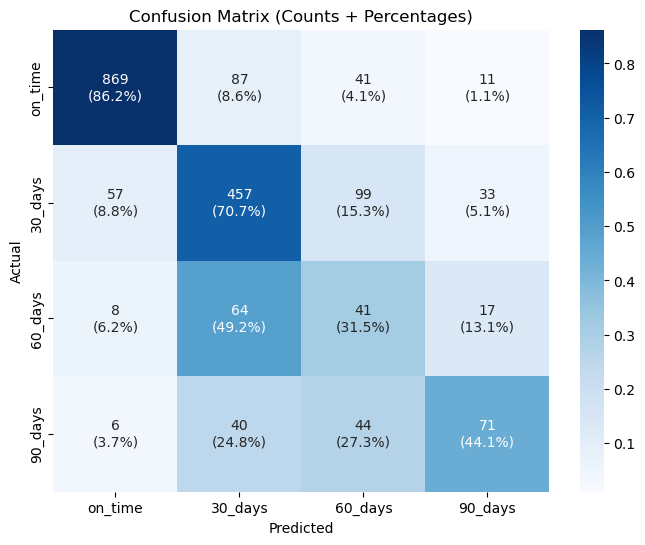

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion matrix (convert to NumPy array)
cm = np.array(result['confusion_matrix'])

# Class mapping
class_mapping = {'on_time': 0, '30_days': 1, '60_days': 2, '90_days': 3}
labels = list(class_mapping.keys())

# Normalize by row (true class)
cm_normalized = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

# Create annotations with both raw counts and percentages
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n({cm_normalized[i, j]:.1%})"

# Plot heatmap using normalized values for color
plt.figure(figsize=(8,6))
sns.heatmap(cm_normalized, annot=annot, fmt="", cmap="Blues",
            xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Counts + Percentages)")
plt.show()

In [ ]:
selected_features

FeatureInfo(
  method      : Two-stage independent feature selection + Stage-1 LDA
  parameters  : threshold='median', stage1_features=24, stage2_features=48
  selected    : 48 features
    · credit_sale_amount
    · dtp_1
    · dtp_2
    · dtp_3
    · dtp_4
    · dtp_avg
    · dtp_wavg
    · dtp_2_trend
    · dtp_3_trend
    · days_since_last_payment
    · amount_due_cumsum
    · amount_paid_cumsum
    · opening_balance
    · plan_type_Plan - A
    · plan_type_Plan - B
    · plan_type_Plan - C
    · plan_type_Plan - D
    · plan_type_Plan - E
    · plan_type_nan
    · due_month
    · due_quarter
    · opening_balance_flag
    · payment_ratio
    · early_payer_flag
    · dtp_rolling_std
    · dtp_max
    · plan_type_risk_score
    · surv_prob_1
    · surv_prob_16
    · surv_prob_30
    · surv_prob_58
    · surv_prob_76
    · surv_prob_118
    · surv_prob_150
    · surv_prob_306
    · surv_prob_324
    · cum_hazard_1
    · cum_hazard_16
    · cum_hazard_30
    · cum_hazard_58
    · cum_

In [ ]:
assert selected_features.weights is not None
df = pd.DataFrame.from_dict(selected_features.weights['stage_1'], orient='index', columns=['value'])
df['value'].sum()

np.float64(1.0)

## 2. Multiple model trainer

In [ ]:
from src.modules.machine_learning import (
    AdaBoostPipeline,
    DecisionTreePipeline,
    GaussianNaiveBayesPipeline,
    KNearestNeighborPipeline,
    RandomForestPipeline,
    XGBoostPipeline,
    OrdinalPipeline,
    TwoStagePipeline,
)

models = {
    "ada_boost":           AdaBoostPipeline,
    "decision_tree":       DecisionTreePipeline,
    "gaussian_naive_bayes": GaussianNaiveBayesPipeline,
    "knn":                 KNearestNeighborPipeline,
    "random_forest":       RandomForestPipeline,
    "xgboost":             XGBoostPipeline,
    "ordinal":             OrdinalPipeline,    # expands to ordinal_xgboost, ordinal_random_forest, ordinal_ada_boost
    "two_stage":           TwoStagePipeline,   # expands to 6 xgb/rf/ada combinations
}

# XGBoost uses GPU acceleration — must run sequentially to avoid CUDA context
# conflicts in the thread pool. The runner auto-extends this list to include
# all expanded model names containing 'xgb' (ordinal_xgboost, two_stage_xgb_*,
# two_stage_ada_xgb), so only the base alias is needed here.
do_not_parallel_compute = ['xgboost']


In [ ]:
from src.modules.machine_learning.utils.features.generate_thresholds import generate_thresholds

# Full strategy matrix: no balancing baseline + all SMOTE variants + hybrid threshold sweep
# smote_enn removed — prior runs showed it consistently underperforms borderline_smote
balance_strategies = ["none", "smote", "borderline_smote", "smote_tomek", "hybrid"]

# Hybrid threshold grid: three representative thresholds (threshold choice is a second-order effect)
thresholds = [0.5, 0.7, 0.9]


In [ ]:
# To silence the error when running knn:
# UserWarning: Could not find the number of physical cores for the following reason:
# [WinError 2]
import os

os.environ['OMP_NUM_THREADS'] = '16'

In [ ]:
# Survival related features
drop_columns = ['censor', 'days_elapsed_until_fully_paid']

# Only extract invoices with payments
df_data = df_credit_sales[df_credit_sales['censor'] == 1]

df_data = df_data.drop(columns=drop_columns)

# Drop invoices with missing critical features
df_data.dropna(subset=['dtp_1', 'dtp_2', 'dtp_3', 'dtp_4'], inplace=True)
df_data

,credit_sale_amount,due_date,dtp_1,dtp_2,dtp_3,dtp_4,dtp_avg,dtp_wavg,dtp_2_trend,dtp_3_trend,...,plan_type_nan,dtp_bracket,due_month,due_quarter,opening_balance_flag,payment_ratio,early_payer_flag,dtp_rolling_std,dtp_max,plan_type_risk_score
1695,2800.0,2022-02-07,24,-5,-2,79,24.00,15.6,-0.491525,-0.412698,...,0.0,on_time,2,1,0,1.000000,0.0,38.910153,79,0
1753,2800.0,2022-04-04,-9,24,-5,-2,2.00,2.4,0.589286,0.034783,...,0.0,on_time,4,2,0,1.000000,1.0,14.944341,24,0
9789,4700.0,2026-02-06,-2,-28,-14,-7,-12.75,-12.7,-0.412698,-0.190476,...,0.0,on_time,2,1,1,0.988662,1.0,11.295279,-2,0
9981,4933.0,2026-03-06,-8,-2,-28,-14,-13.00,-10.8,0.214286,-0.219780,...,0.0,on_time,3,1,0,1.000000,1.0,11.135529,-2,0
584,2900.0,2019-12-06,33,193,152,284,165.50,129.9,6.400000,0.619792,...,0.0,30_days,12,4,1,0.905309,0.0,104.142531,284,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9792,5800.0,2026-02-06,34,34,24,12,26.00,29.8,0.000000,-0.158730,...,0.0,30_days,2,1,1,0.972245,0.0,10.456258,34,0
9869,1500.0,2026-02-18,3,34,34,24,23.75,20.6,2.583333,0.413333,...,0.0,60_days,2,1,1,0.992873,0.0,14.614491,34,0
9942,400.0,2026-03-05,33,3,34,34,26.00,24.3,-2.000000,0.037037,...,0.0,30_days,3,1,1,0.990990,0.0,15.340578,34,0
9967,5800.0,2026-03-06,6,33,3,34,19.00,16.3,27.000000,-0.187500,...,0.0,30_days,3,1,1,0.964462,0.0,16.792856,34,0


In [ ]:
import time
from src.modules.machine_learning.utils.training.run_models_parallel import SurvivalExperimentRunner
from src.modules.machine_learning.utils.io.save_results_to_folder import save_training_results

# Record start time
_train_start = time.time()
_train_start_iso = time.strftime("%Y-%m-%dT%H:%M:%S", time.localtime(_train_start))

# Create an experiment runner instance
runner = SurvivalExperimentRunner(
    df_data=df_data,
    df_data_surv=df_data_surv,
    models=models,
    balance_strategies=balance_strategies,
    args=args,
    best_parameters=best_surv_parameters,
    thresholds=thresholds,
    n_jobs=-1,
    do_not_parallel_compute=do_not_parallel_compute,
    feature_selection_baseline=True,
    feature_selection_enhanced=True,
    checkpoint_path = os.path.join(settings['Training']['LOGS'], "_checkpoint.pkl"),
)

# Run all experiments — returns (results_df, class_mappings)
df_results, class_mappings = runner.run()

# Record end time
_train_end = time.time()
_train_end_iso = time.strftime("%Y-%m-%dT%H:%M:%S", time.localtime(_train_end))
_elapsed_s = int(_train_end - _train_start)
_elapsed_str = f"{_elapsed_s // 3600}h {(_elapsed_s % 3600) // 60}m {_elapsed_s % 60}s"
print(f"\nTotal training time: {_elapsed_str}")

# Save results to a new dated folder under Results/
survival_results_dict = {
    "best_c_index":      tuner.best_c_index_,
    "best_parameters":   best_surv_parameters,
    "time_points":       best_time_points,
}

metadata, run_folder = save_training_results(
    model_results_df     = df_results,
    survival_results_dict= survival_results_dict,
    class_mappings_dict  = class_mappings,
    base_output_folder   = settings['Training']['RESULTS_ROOT'],
    model_names          = list(models.keys()),
    start_time           = _train_start_iso,
    end_time             = _train_end_iso,
    total_run_time       = _elapsed_str,
    format               = "sqlite",
)

print(f"Results saved → {run_folder}")


[dataset] Preparing: none ...
[dataset]   Generating survival features ...
[dataset]   Done (3s)
[dataset] Preparing: smote ...
[dataset]   Generating survival features ...
[dataset]   Done (4s)
[dataset] Preparing: borderline_smote ...
[dataset]   Generating survival features ...
[dataset]   Done (4s)
[dataset] Preparing: smote_tomek ...
[dataset]   Generating survival features ...
[dataset]   Done (4s)
[dataset] Preparing: hybrid@0.5 ...
[dataset]   Generating survival features ...
[dataset]   Done (3s)
[dataset] Preparing: hybrid@0.7 ...
[dataset]   Generating survival features ...
[dataset]   Done (2s)
[dataset] Preparing: hybrid@0.9 ...
[dataset]   Generating survival features ...
[dataset]   Done (2s)
[1/1092] parallel task done | Elapsed: 4s | ETA: ~80m 23s remaining
[2/1092] parallel task done | Elapsed: 4s | ETA: ~40m 25s remaining
[3/1092] parallel task done | Elapsed: 4s | ETA: ~27m 12s remaining
[4/1092] parallel task done | Elapsed: 4s | ETA: ~20m 32s remaining
[5/1092] pa

c:\Users\rjbel\anaconda3\envs\Thesis_IPPP\Lib\site-packages\xgboost\training.py:200: UserWarning: [05:51:35] WARNING: C:\Users\task_177203131132615\croot\xgboost-split_1772031744563\work\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\rjbel\anaconda3\envs\Thesis_IPPP\Lib\site-packages\xgboost\training.py:200: UserWarning: [05:51:35] WARNING: C:\Users\task_177203131132615\croot\xgboost-split_1772031744563\work\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\rjbel\anaconda3\envs\Thesis_IPPP\Lib\site-packages\xgboost\training.py:200: UserWarning: [05:51:36] WARNING: C:\Users\task_177203131132615\croot\xgboost-split_1772031744563\work\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration

[631/1092] xgboost | Elapsed: 28m 27s | ETA: ~20m 47s remaining


c:\Users\rjbel\anaconda3\envs\Thesis_IPPP\Lib\site-packages\xgboost\training.py:200: UserWarning: [05:51:37] WARNING: C:\Users\task_177203131132615\croot\xgboost-split_1772031744563\work\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\rjbel\anaconda3\envs\Thesis_IPPP\Lib\site-packages\xgboost\training.py:200: UserWarning: [05:51:38] WARNING: C:\Users\task_177203131132615\croot\xgboost-split_1772031744563\work\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\rjbel\anaconda3\envs\Thesis_IPPP\Lib\site-packages\xgboost\training.py:200: UserWarning: [05:51:39] WARNING: C:\Users\task_177203131132615\croot\xgboost-split_1772031744563\work\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration

[632/1092] xgboost | Elapsed: 28m 31s | ETA: ~20m 45s remaining


...

c:\Users\rjbel\anaconda3\envs\Thesis_IPPP\Lib\site-packages\xgboost\training.py:200: UserWarning: [06:23:05] WARNING: C:\Users\task_177203131132615\croot\xgboost-split_1772031744563\work\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\rjbel\anaconda3\envs\Thesis_IPPP\Lib\site-packages\xgboost\training.py:200: UserWarning: [06:23:06] WARNING: C:\Users\task_177203131132615\croot\xgboost-split_1772031744563\work\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\rjbel\anaconda3\envs\Thesis_IPPP\Lib\site-packages\xgboost\training.py:200: UserWarning: [06:23:07] WARNING: C:\Users\task_177203131132615\croot\xgboost-split_1772031744563\work\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration

[985/1092] two_stage_xgb_xgb | Elapsed: 60m 00s | ETA: ~6m 31s remaining


c:\Users\rjbel\anaconda3\envs\Thesis_IPPP\Lib\site-packages\xgboost\training.py:200: UserWarning: [06:23:11] WARNING: C:\Users\task_177203131132615\croot\xgboost-split_1772031744563\work\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\rjbel\anaconda3\envs\Thesis_IPPP\Lib\site-packages\xgboost\training.py:200: UserWarning: [06:23:12] WARNING: C:\Users\task_177203131132615\croot\xgboost-split_1772031744563\work\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\rjbel\anaconda3\envs\Thesis_IPPP\Lib\site-packages\xgboost\training.py:200: UserWarning: [06:23:12] WARNING: C:\Users\task_177203131132615\croot\xgboost-split_1772031744563\work\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration

[986/1092] two_stage_xgb_xgb | Elapsed: 60m 04s | ETA: ~6m 27s remaining


c:\Users\rjbel\anaconda3\envs\Thesis_IPPP\Lib\site-packages\xgboost\training.py:200: UserWarning: [06:23:15] WARNING: C:\Users\task_177203131132615\croot\xgboost-split_1772031744563\work\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
df_results

In [ ]:
df_results.sort_values(by='enhanced_accuracy', ascending=False)

In [ ]:
df_results.sort_values(by='enhanced_precision_macro', ascending=False)

In [ ]:
df_results.sort_values(by='enhanced_f1_macro', ascending=False)

In [ ]:
df_results.sort_values(by='enhanced_roc_auc_macro', ascending=False)

In [ ]:
import sqlite3
import os
import pandas as pd

# ── Load results from the current run's SQLite database ──────────────────────
# run_folder is set by the training cell above (e.g. "Results\2026_04_18_01")
db_path = os.path.join(run_folder, "results.db")
con = sqlite3.connect(db_path)

df = pd.read_sql_query("""
    SELECT
        e.model,
        e.balance_strategy,
        e.parameters,
        MAX(CASE WHEN m.phase = 'baseline' THEN m.accuracy      END) AS baseline_accuracy,
        MAX(CASE WHEN m.phase = 'baseline' THEN m.f1_macro      END) AS baseline_f1_macro,
        MAX(CASE WHEN m.phase = 'baseline' THEN m.roc_auc_macro END) AS baseline_roc_auc_macro,
        MAX(CASE WHEN m.phase = 'enhanced' THEN m.accuracy      END) AS enhanced_accuracy,
        MAX(CASE WHEN m.phase = 'enhanced' THEN m.f1_macro      END) AS enhanced_f1_macro,
        MAX(CASE WHEN m.phase = 'enhanced' THEN m.roc_auc_macro END) AS enhanced_roc_auc_macro
    FROM experiments e
    JOIN metrics m ON m.experiment_id = e.id
    GROUP BY e.id
""", con)
con.close()

# NOTE: undersample_threshold is not stored in this run's DB.
# Hybrid variants (threshold 0.5 / 0.7 / 0.9) are merged under one 'hybrid' label.
# Their mean score is averaged across all three threshold variants.

# Choose which score column to use
score_column = "enhanced_roc_auc_macro"   # <-- change this to the metric you want

# Compute mean score per model + parameters + balance strategy
grouped = (
    df.groupby(["model", "parameters", "balance_strategy"])[score_column]
    .mean()
    .reset_index()
)

# Rank strategies within each model+parameters group
grouped["rank"] = (
    grouped.groupby(["model", "parameters"])[score_column]
           .rank(method="first", ascending=False)
)

# Assign weighted points: top 1 → 5, top 2 → 4, … top 5 → 1
def assign_points(rank):
    if rank == 1: return 5
    elif rank == 2: return 4
    elif rank == 3: return 3
    elif rank == 4: return 2
    elif rank == 5: return 1
    else: return 0

grouped["points"] = grouped["rank"].apply(assign_points)

# Aggregate across all models to see total points per strategy
strategy_scores = (
    grouped.groupby("balance_strategy")["points"]
    .sum()
    .reset_index()
    .sort_values("points", ascending=False)
)

print("Weighted ranking per model+parameters:")
print(grouped.sort_values(["model", "parameters", "rank"]).to_string())

print("\nGlobal tally of weighted points per balance strategy:")
print(strategy_scores.to_string(index=False))


In [ ]:
import sqlite3
import os
import pandas as pd

# ── Load results from the current run's SQLite database ──────────────────────
# run_folder is set by the training cell above (e.g. "Results\2026_04_18_01")
db_path = os.path.join(run_folder, "results.db")
con = sqlite3.connect(db_path)

df = pd.read_sql_query("""
    SELECT
        e.model,
        e.balance_strategy,
        e.parameters,
        MAX(CASE WHEN m.phase = 'baseline' THEN m.accuracy      END) AS baseline_accuracy,
        MAX(CASE WHEN m.phase = 'baseline' THEN m.f1_macro      END) AS baseline_f1_macro,
        MAX(CASE WHEN m.phase = 'baseline' THEN m.roc_auc_macro END) AS baseline_roc_auc_macro,
        MAX(CASE WHEN m.phase = 'enhanced' THEN m.accuracy      END) AS enhanced_accuracy,
        MAX(CASE WHEN m.phase = 'enhanced' THEN m.f1_macro      END) AS enhanced_f1_macro,
        MAX(CASE WHEN m.phase = 'enhanced' THEN m.roc_auc_macro END) AS enhanced_roc_auc_macro
    FROM experiments e
    JOIN metrics m ON m.experiment_id = e.id
    GROUP BY e.id
""", con)
con.close()

# NOTE: undersample_threshold is not stored in this run's DB.
# Hybrid variants (threshold 0.5 / 0.7 / 0.9) are merged under one 'hybrid' label.
# Their mean score is averaged across all three threshold variants.

# Choose which score column to use
score_column = "enhanced_f1_macro"   # <-- change this to the metric you want

# Compute mean score per model + parameters + balance strategy
grouped = (
    df.groupby(["model", "parameters", "balance_strategy"])[score_column]
    .mean()
    .reset_index()
)

# Rank strategies within each model+parameters group
grouped["rank"] = (
    grouped.groupby(["model", "parameters"])[score_column]
           .rank(method="first", ascending=False)
)

# Assign weighted points: top 1 → 5, top 2 → 4, … top 5 → 1
def assign_points(rank):
    if rank == 1: return 5
    elif rank == 2: return 4
    elif rank == 3: return 3
    elif rank == 4: return 2
    elif rank == 5: return 1
    else: return 0

grouped["points"] = grouped["rank"].apply(assign_points)

# Aggregate across all models to see total points per strategy
strategy_scores = (
    grouped.groupby("balance_strategy")["points"]
    .sum()
    .reset_index()
    .sort_values("points", ascending=False)
)

print("Weighted ranking per model+parameters:")
print(grouped.sort_values(["model", "parameters", "rank"]).to_string())

print("\nGlobal tally of weighted points per balance strategy:")
print(strategy_scores.to_string(index=False))


## 3. Forecasting pipeline

In [ ]:
from src.modules.feature_engineering.credit_sales_machine_learning import CreditSalesProcessor

cs_test = CreditSalesProcessor(df_revenues, df_enrollees, args,
                      drop_fully_paid_invoices=True,
                      drop_back_account_transactions=True,
                      calculate_payment_amounts=True,
                      add_description=True,
                      drop_missing_dtp=False)
df_cs_test = cs_test.show_data()
df_cs_test